# **함수의 연속**

In [1]:
import matplotlib.pyplot as plt
import numpy as np

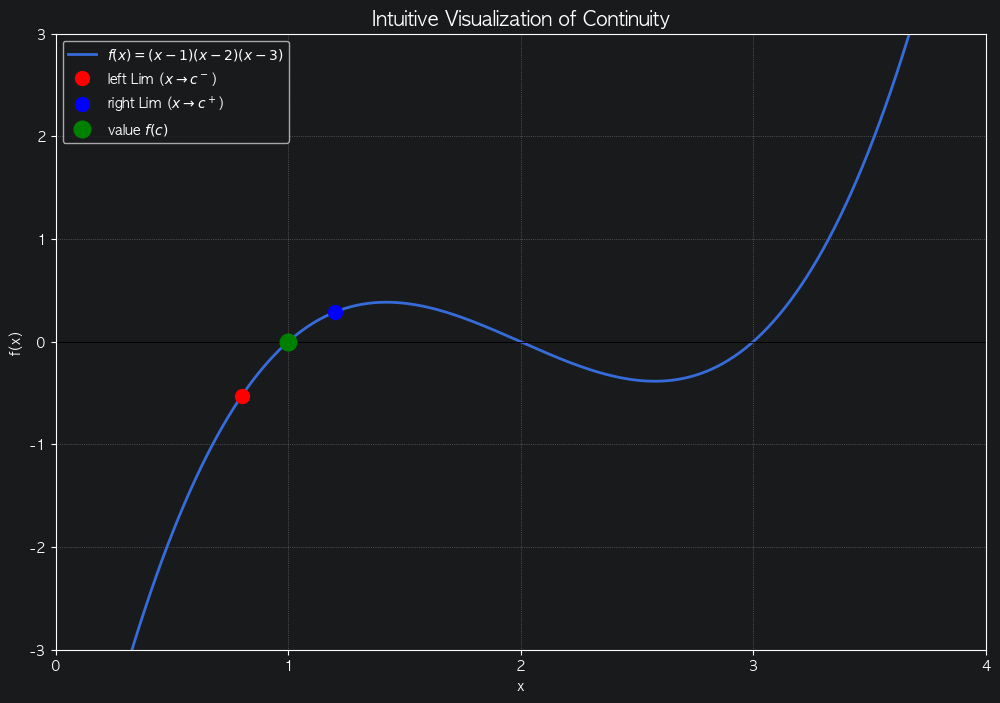

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.animation import FuncAnimation

f = lambda x: (x - 1) * (x - 2) * (x - 3)
x = np.linspace(0, 4, 500)
y = f(x)

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(x, y, lw=2, color='C0', label='$f(x)=(x-1)(x-2)(x-3)$')
ax.axhline(0, color='k', lw=0.7)
ax.axvline(0, color='k', lw=0.7)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_xlim(0, 4)
ax.set_ylim(-3, 3)
ax.grid(True, linestyle=':', alpha=0.6)

left_limit_dot, = ax.plot([], [], 'ro', markersize=10, label='left Lim ($x \\to c^-$)')
right_limit_dot, = ax.plot([], [], 'bo', markersize=10, label='right Lim ($x \\to c^+$)')
f_c_dot, = ax.plot([], [], 'go', markersize=12, zorder=5, label='value $f(c)$')

ax.legend(loc='upper left')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Intuitive Visualization of Continuity', fontsize=14)

def update(frame):
    c = 1.0 + frame * 0.02
    delta = 0.2

    left_x, left_y = c - delta, f(c - delta)
    right_x, right_y = c + delta, f(c + delta)
    cx, cy = c, f(c)

    left_limit_dot.set_data([left_x], [left_y])
    right_limit_dot.set_data([right_x], [right_y])
    f_c_dot.set_data([cx], [cy])

    return left_limit_dot, right_limit_dot, f_c_dot

ani = FuncAnimation(fig, update, frames=100, interval=50, blit=True)
plt.show()


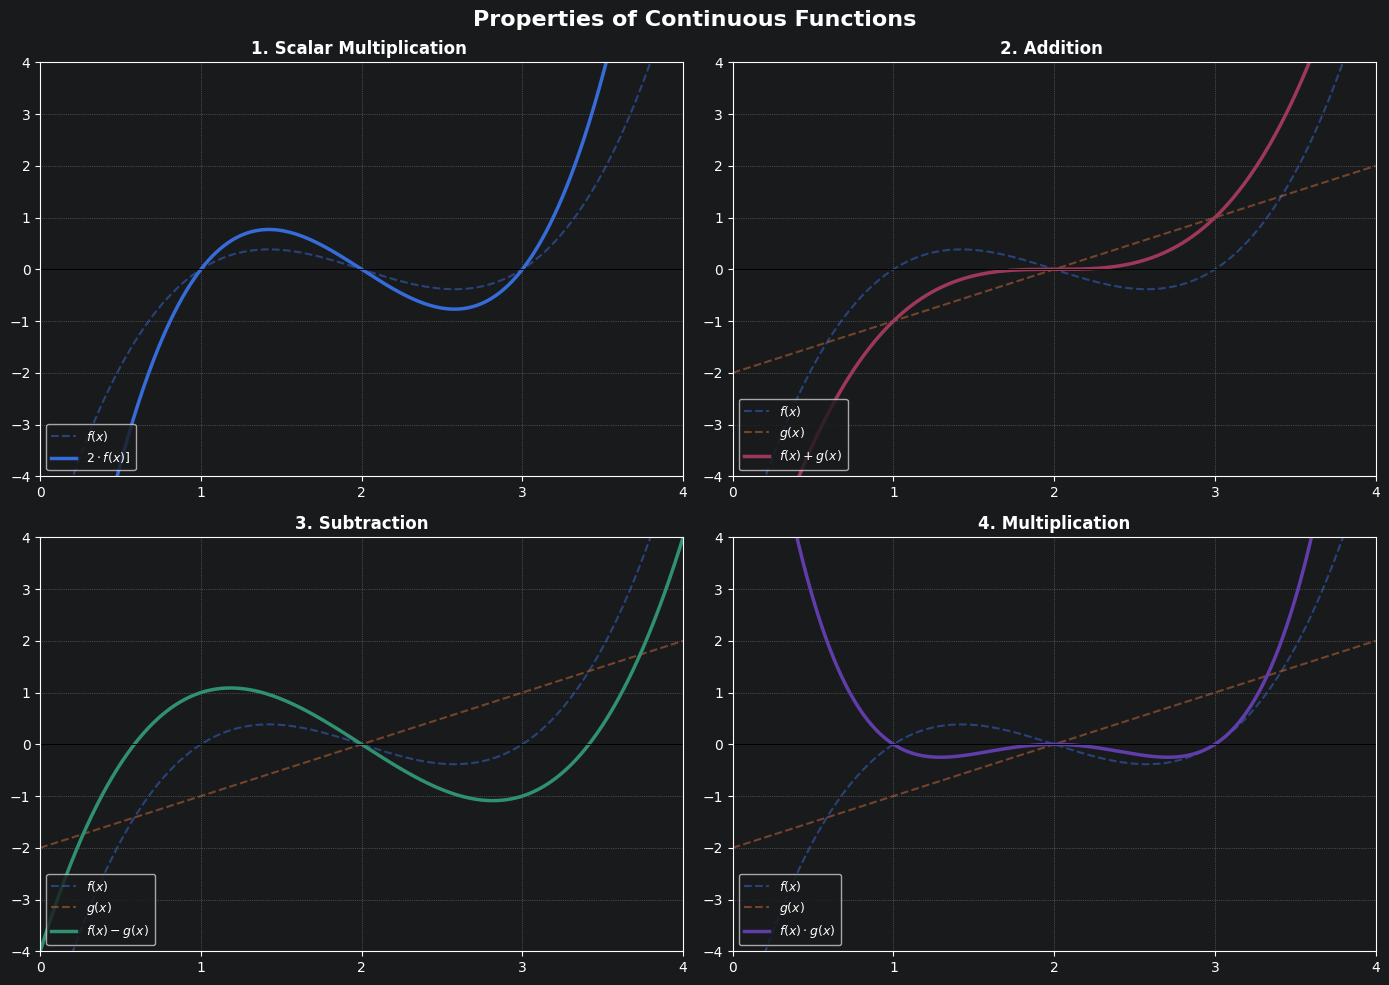

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

f = lambda x: (x - 1) * (x - 2) * (x - 3)
g = lambda x: x - 2
x = np.linspace(0, 4, 500)

f_scalar = lambda x: 2 * f(x)
f_add    = lambda x: f(x) + g(x)
f_sub    = lambda x: f(x) - g(x)
f_mul    = lambda x: f(x) * g(x)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()

def setup_axis(ax, title):
    ax.axhline(0, color='k', lw=0.7)
    ax.axvline(0, color='k', lw=0.7)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.set_xlim(0, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower left', fontsize=9)

axs[0].plot(x, f(x), 'C0--', alpha=0.5, label='$f(x)$')
axs[0].plot(x, f_scalar(x), 'C0', lw=2.5, label='$2 \\cdot f(x)$]')
setup_axis(axs[0], '1. Scalar Multiplication ')

axs[1].plot(x, f(x), 'C0--', alpha=0.5, label='$f(x)$')
axs[1].plot(x, g(x), 'C1--', alpha=0.5, label='$g(x)$')
axs[1].plot(x, f_add(x), 'C2', lw=2.5, label='$f(x) + g(x)$ ')
setup_axis(axs[1], '2. Addition ')

axs[2].plot(x, f(x), 'C0--', alpha=0.5, label='$f(x)$')
axs[2].plot(x, g(x), 'C1--', alpha=0.5, label='$g(x)$')
axs[2].plot(x, f_sub(x), 'C3', lw=2.5, label='$f(x) - g(x)$ ')
setup_axis(axs[2], '3. Subtraction')

axs[3].plot(x, f(x), 'C0--', alpha=0.5, label='$f(x)$')
axs[3].plot(x, g(x), 'C1--', alpha=0.5, label='$g(x)$')
axs[3].plot(x, f_mul(x), 'C4', lw=2.5, label='$f(x) \\cdot g(x)$ ')
setup_axis(axs[3], '4. Multiplication')

plt.suptitle('Properties of Continuous Functions', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


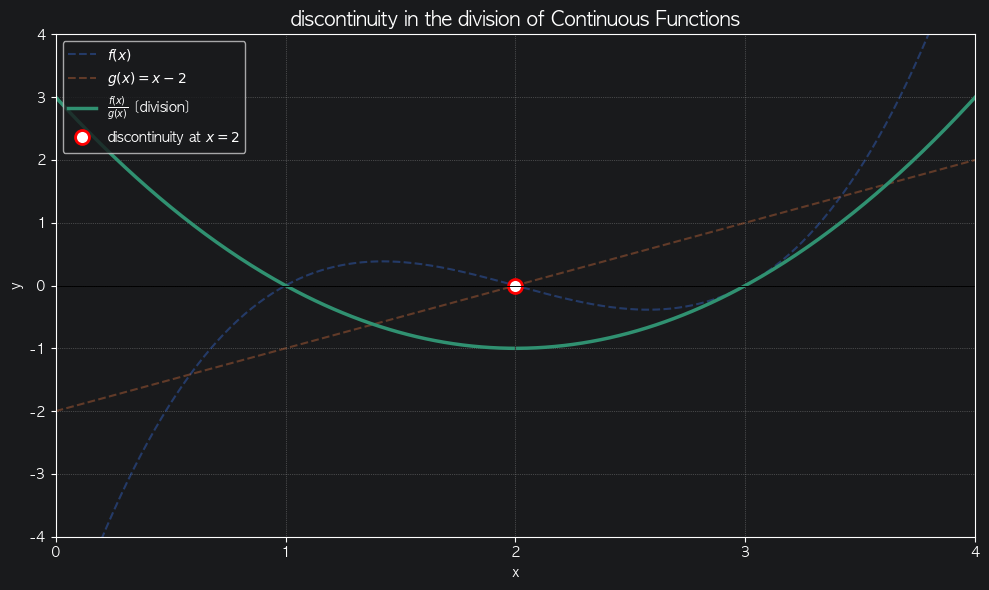

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

f = lambda x: (x - 1) * (x - 2) * (x - 3)
g = lambda x: x - 2

x_left = np.linspace(0, 1.99, 200)
x_right = np.linspace(2.01, 4, 200)

f_div_left = f(x_left) / g(x_left)
f_div_right = f(x_right) / g(x_right)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(np.linspace(0, 4, 400), f(np.linspace(0, 4, 400)), 'C0--', alpha=0.4, label='$f(x)$')
ax.plot(np.linspace(0, 4, 400), g(np.linspace(0, 4, 400)), 'C1--', alpha=0.4, label='$g(x) = x-2$')

ax.plot(x_left, f_div_left, 'C3', lw=2.5, label=r'$\frac{f(x)}{g(x)}$ [division]')
ax.plot(x_right, f_div_right, 'C3', lw=2.5)

ax.plot(2, 0, 'ro', markerfacecolor='white', markersize=10, mew=2, label='discontinuity at $x=2$')

ax.axhline(0, color='k', lw=0.7)
ax.axvline(0, color='k', lw=0.7)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_xlim(0, 4)
ax.set_ylim(-4, 4)
ax.grid(True, linestyle=':', alpha=0.6)

ax.set_title('discontinuity in the division of Continuous Functions', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


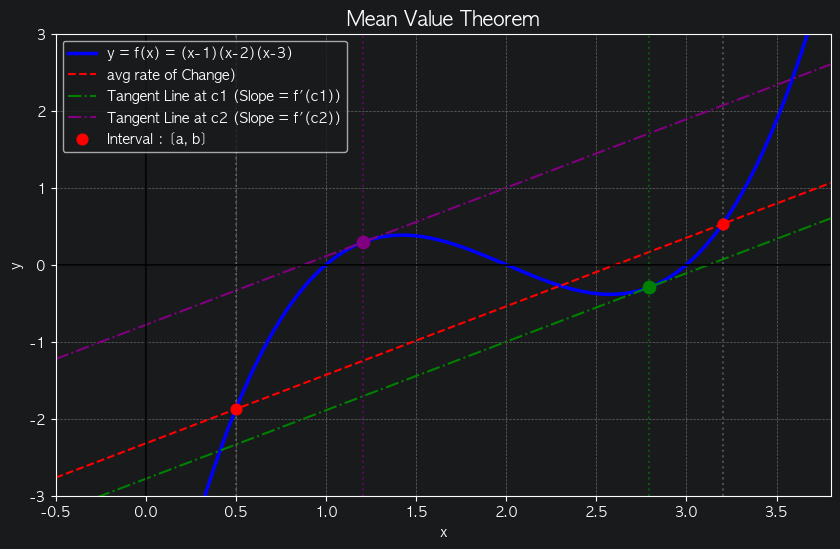

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (x - 1) * (x - 2) * (x - 3)

a, b = 0.5, 3.2
fa, fb = f(a), f(b)

secant_slope = (fb - fa) / (b - a)

coefficients = [3, -12, 11 - secant_slope]
roots = np.roots(coefficients)

c_list = [r for r in roots if a < r < b]

x_vals = np.linspace(-0.5, 3.8, 300)
y_vals = f(x_vals)
secant_line = secant_slope * (x_vals - a) + fa

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', label='y = f(x) = (x-1)(x-2)(x-3)', linewidth=2.5)
plt.plot(x_vals, secant_line, 'r--', label='avg rate of Change)')

colors = ['green', 'purple']
for i, c_val in enumerate(c_list):
    fc_val = f(c_val)
    tangent_line = secant_slope * (x_vals - c_val) + fc_val

    plt.plot(x_vals, tangent_line, color=colors[i], linestyle='-.',
             label=f"Tangent Line at c{i+1} (Slope = f'(c{i+1}))")

    plt.scatter([c_val], [fc_val], color=colors[i], marker='o', s=80, zorder=5)
    plt.axvline(x=c_val, color=colors[i], linestyle=':', alpha=0.6)

plt.scatter([a, b], [fa, fb], color='red', s=60, zorder=5, label='Interval : [a, b]')
plt.axvline(x=a, color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=b, color='gray', linestyle=':', alpha=0.5)

plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)

plt.xlim(-0.5, 3.8)
plt.ylim(-3.0, 3.0)

plt.title('Mean Value Theorem', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
